In [1]:
OPENAI_KEY = "INSERT_KEY"
GEMINI_KEY = "INSERT_KEY"
CLAUDE_KEY = "INSERT_KEY"

In [4]:
import os, re, time
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import google.generativeai as genai
from sentence_transformers import SentenceTransformer

# --- 2. UTILITY FUNCTIONS ---
def super_clean_id(filename):
    nums = re.findall(r"(\d+)", str(filename))
    return str(int(nums[-1])) if nums else str(filename).split('.')[0].strip().lower()

def load_dir_robust(folder):
    texts = {}
    if not folder.is_dir(): return texts
    for fn in os.listdir(folder):
        if fn.lower().endswith(".txt"):
            eid = super_clean_id(fn)
            with open(folder / fn, "r", encoding="utf-8", errors="ignore") as f:
                texts[eid] = f.read().strip()
    return texts

def get_embeddings_batched(text_list, model_id):
    if "models/" in model_id:
        result = genai.embed_content(model=model_id, content=text_list, task_type="clustering")
        return np.array(result['embedding'])
    return SentenceTransformer(model_id).encode(text_list, show_progress_bar=False)


# --- 1. CONFIGURATION ---
genai.configure(api_key=GEMINI_KEY)

ARGREWRITE_ROOT = Path("../ArgRewrite").resolve()
D1_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft1"
D2_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft2"

EMBEDDING_MODELS = {
    "MiniLM-L6": "all-miniLM-L6-v2",
    "Gemini-004": "models/text-embedding-004"
}
# CUSTOMIZE LLM NAMES HERE
# Format: "FOLDER_NAME_UPPER": "Display Name"

# --- 1. CONFIGURATION ---
LLM_DISPLAY_NAMES = {
    "CLAUDE-HAIKU-4-5-20251001": "claude 3.5 haiku",
    "GEMINI-2.5-FLASH": "gemini 2.5 flash",
    "GPT-5-MINI": "gpt-5-mini",
    # "GPT-4O-MINI": "gpt-4o-mini"
}

VARIANT_COLORS = {
    "minimal": "#d95f02", "grammar": "#1b9e77", "general": "#b2182b",
    "completion": "#ce1256", "expansion": "#7570b3"
}

DESCRIPTIVE_NAMES = {
    "minimal": "Minimal Edit", "grammar": "Grammar Edits",
    "completion": "Completion", "expansion": "Expansion", "general": "General Revision",
}

PLOT_ORDER = ["general", "minimal", "grammar", "completion", "expansion"]

# --- 3. DATA AGGREGATION ---
d1_map, d2_map = load_dir_robust(D1_PATH), load_dir_robust(D2_PATH)
common_ids = sorted(set(d1_map.keys()) & set(d2_map.keys()), key=lambda x: int(x))
df_human = pd.DataFrame([{"essay_id": eid, "draft1": d1_map[eid], "draft2": d2_map[eid]} for eid in common_ids])

MODEL_DIRS = [p for p in Path(".").iterdir() if p.is_dir() and p.name.startswith("llm_drafts")]
all_data_list = []

for folder in MODEL_DIRS:
    model_tag = folder.name.replace("llm_drafts_", "").upper()
    for csv_path in folder.glob("*.csv"):
        v_key = "general" if any(x in csv_path.name.lower() for x in ["expert", "general"]) \
                else next((v for v in PLOT_ORDER if v in csv_path.name.lower()), None)
        if not v_key: continue
        ldf = pd.read_csv(csv_path)
        ldf['essay_id'] = ldf['essay_id'].apply(super_clean_id)
        ai_col = 'output_text' if 'output_text' in ldf.columns else 'final_llm_text'
        merged = pd.merge(df_human, ldf[['essay_id', ai_col]], on='essay_id').rename(columns={ai_col: 'ai_text'})
        merged['llm_model'], merged['mode'] = model_tag, v_key
        merged['feedback'] = "WITH" if "with_FB" in csv_path.name else "WITHOUT"
        all_data_list.append(merged)

df_master = pd.concat(all_data_list)

Loading human essays...
Loading LLM drafts...
Total rows to process: 2580
Generating plot for general (NO_FB)...


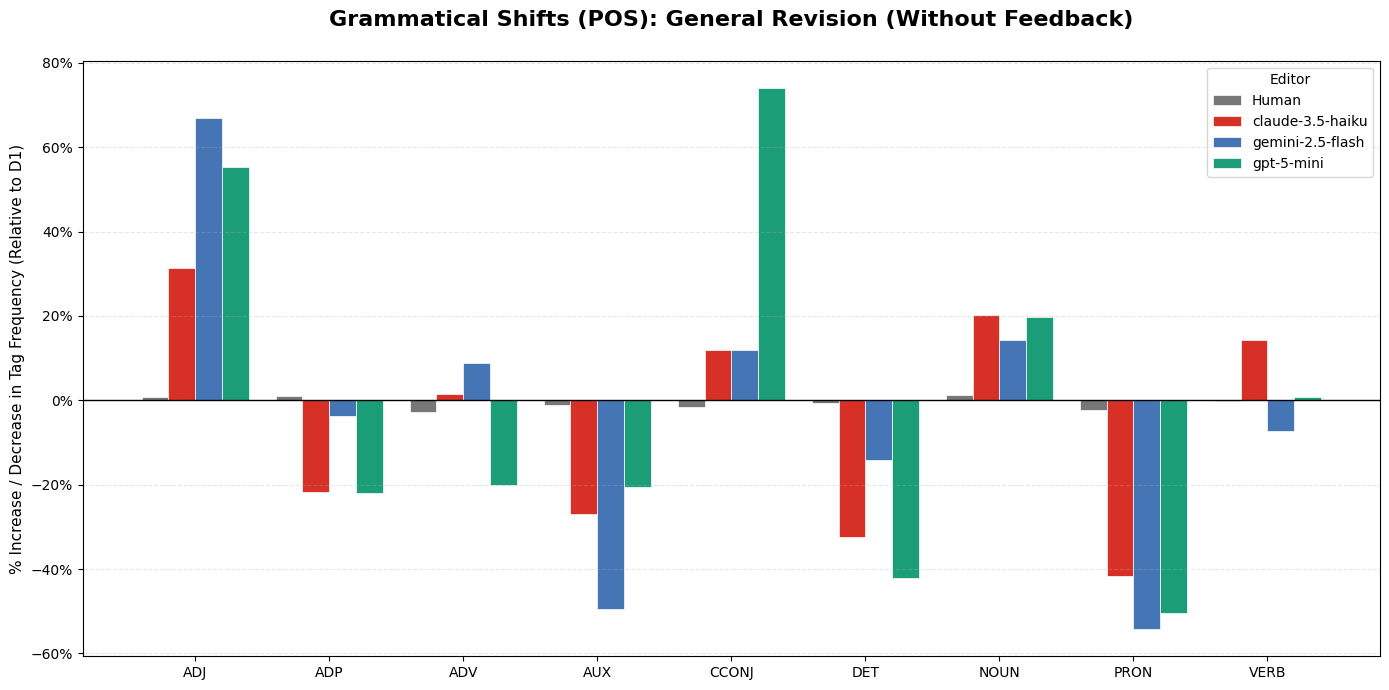

Generating plot for general (WITH_FB)...


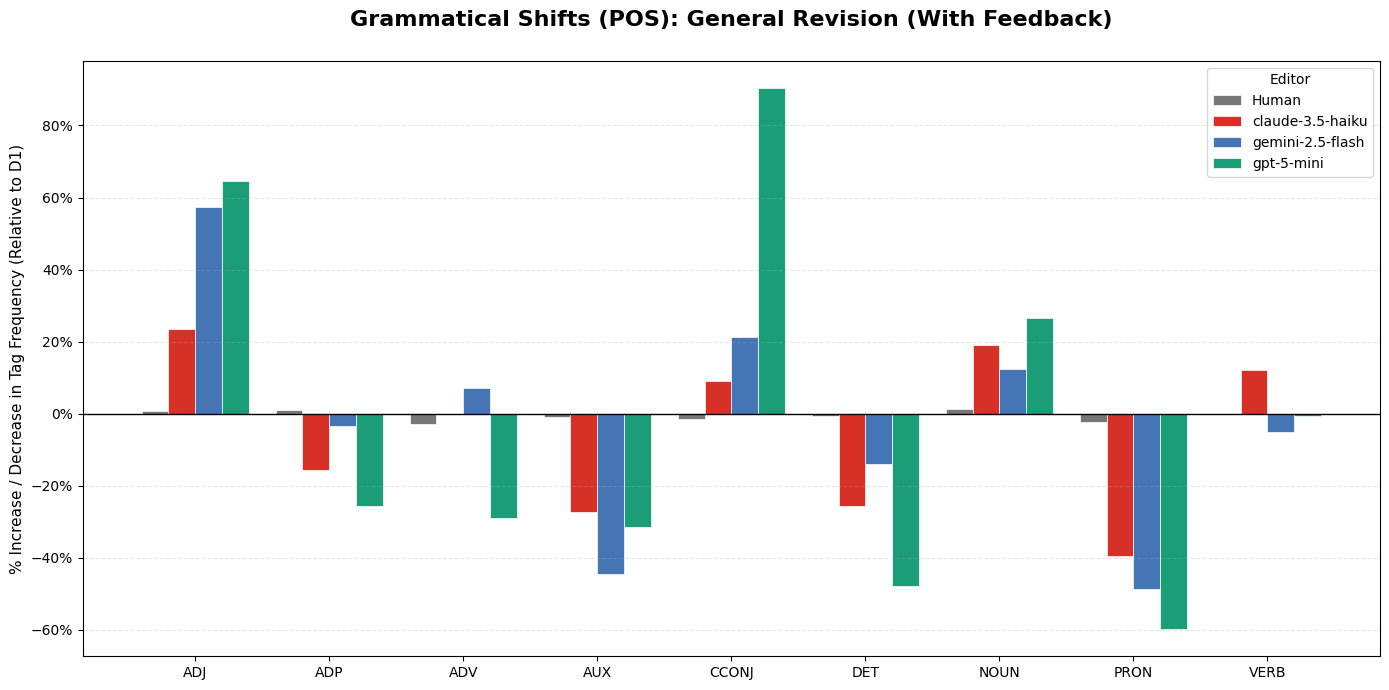

Generating plot for minimal (NO_FB)...


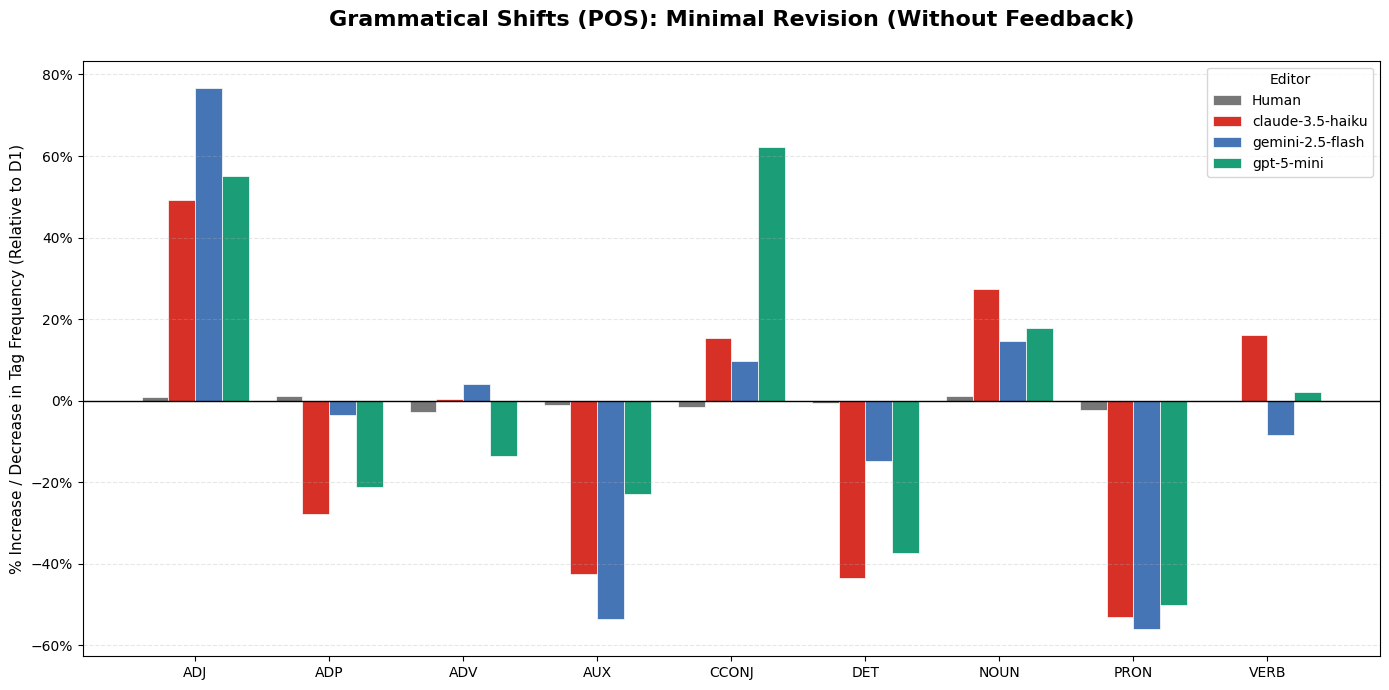

Generating plot for minimal (WITH_FB)...


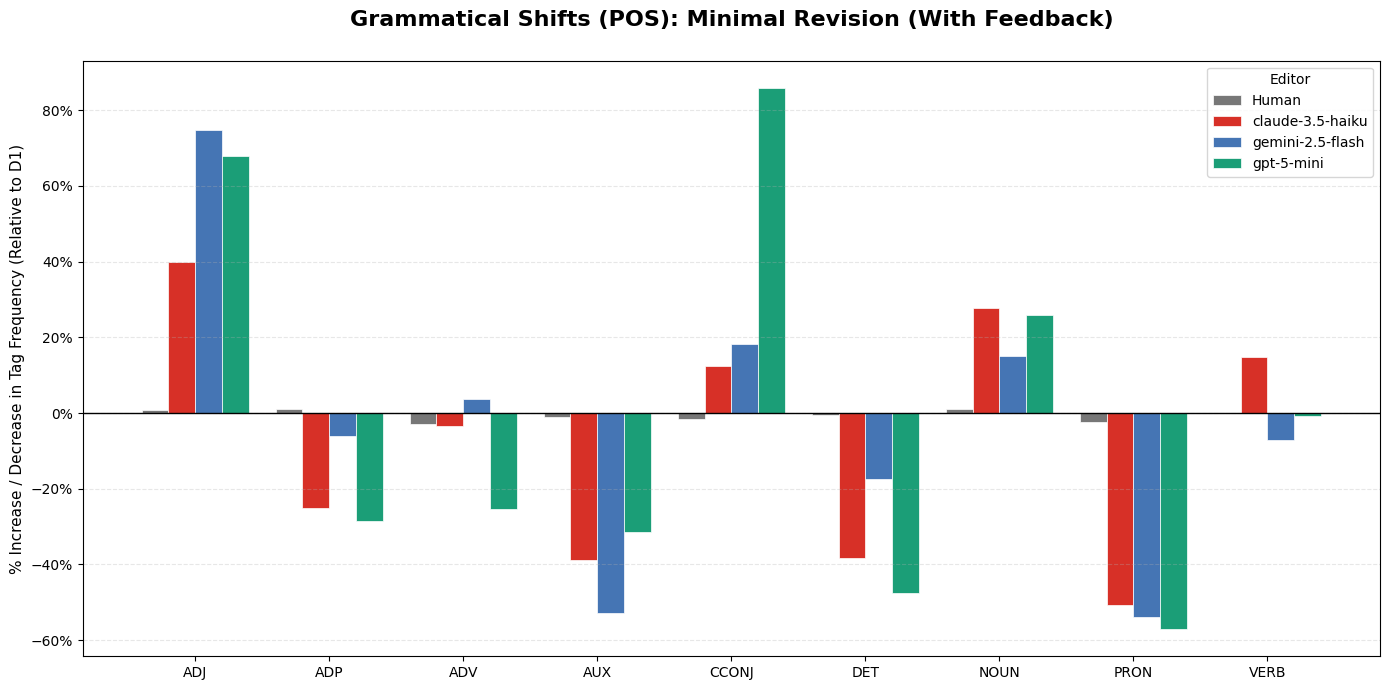

Generating plot for grammar (NO_FB)...


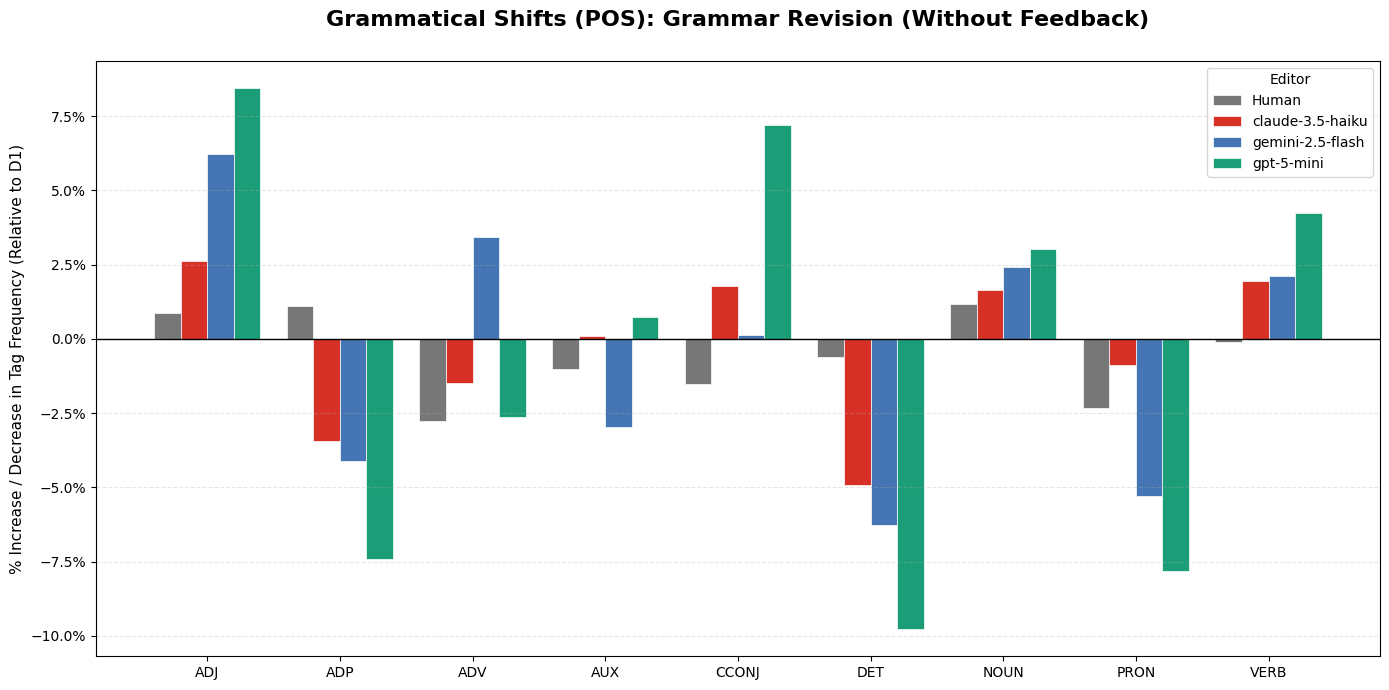

Generating plot for grammar (WITH_FB)...


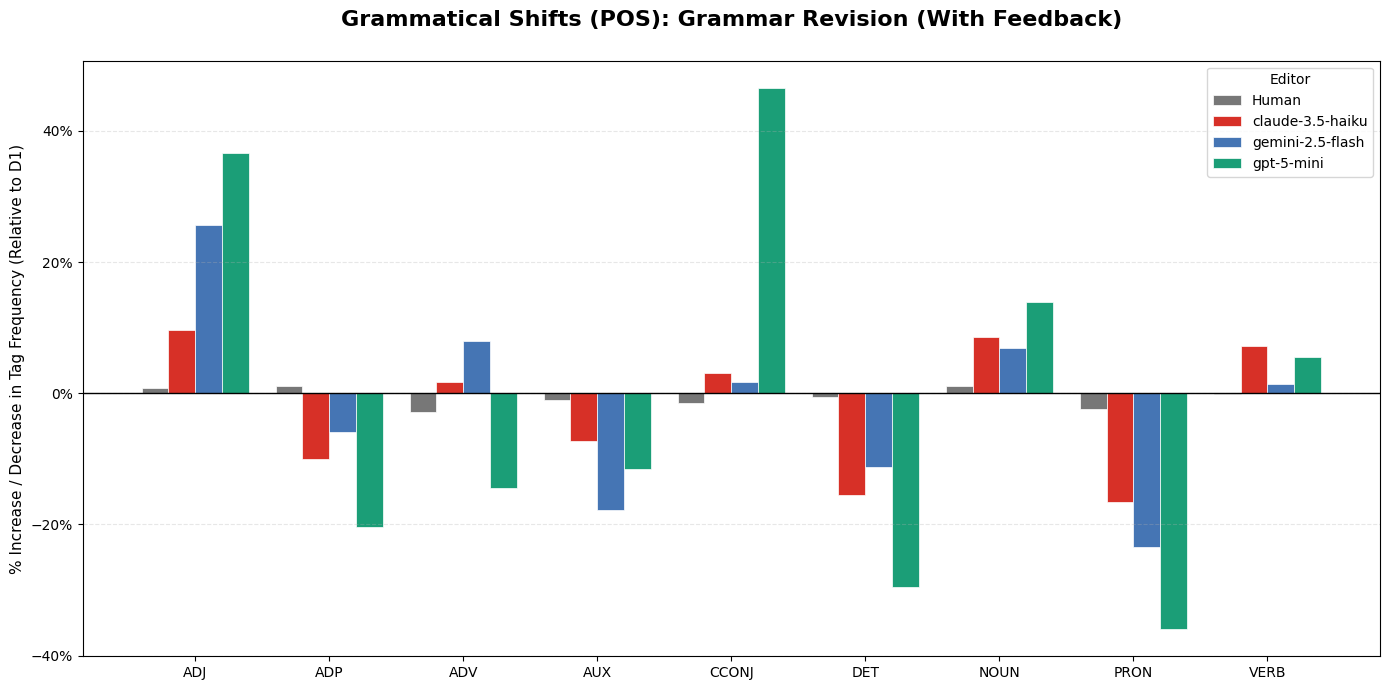

Generating plot for completion (NO_FB)...


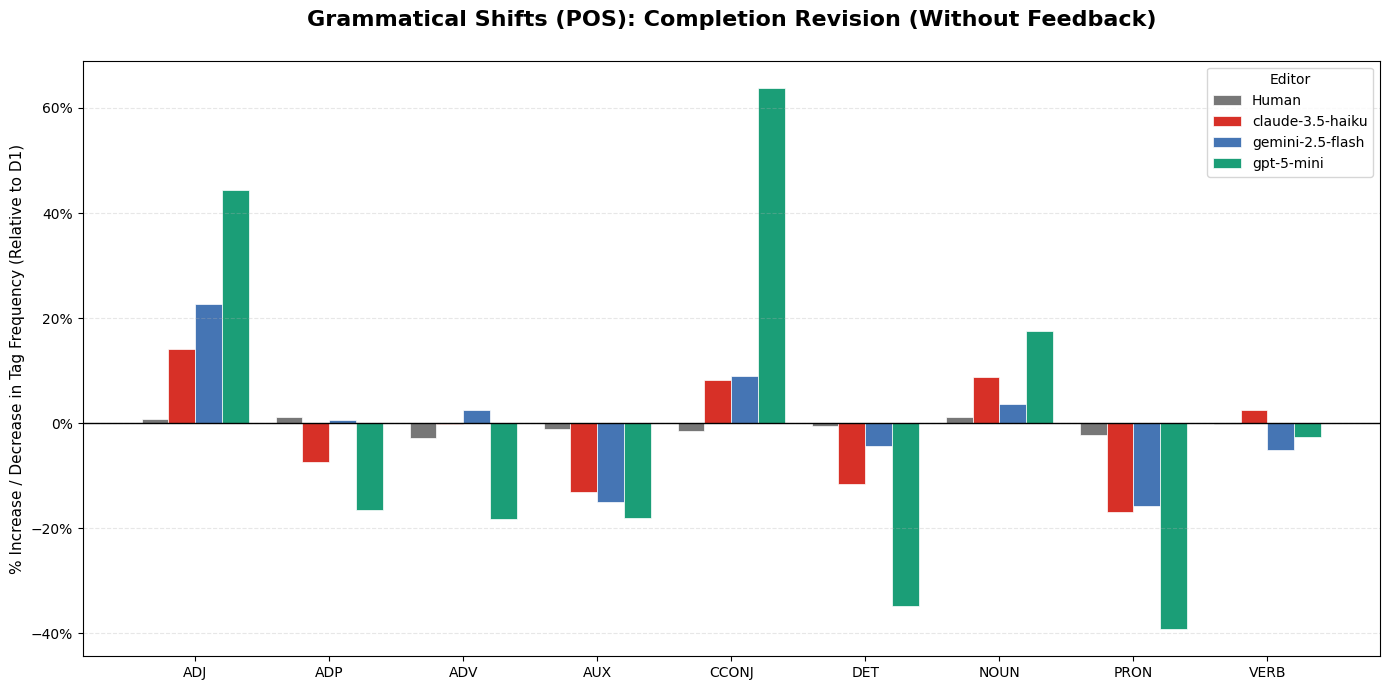

Generating plot for completion (WITH_FB)...


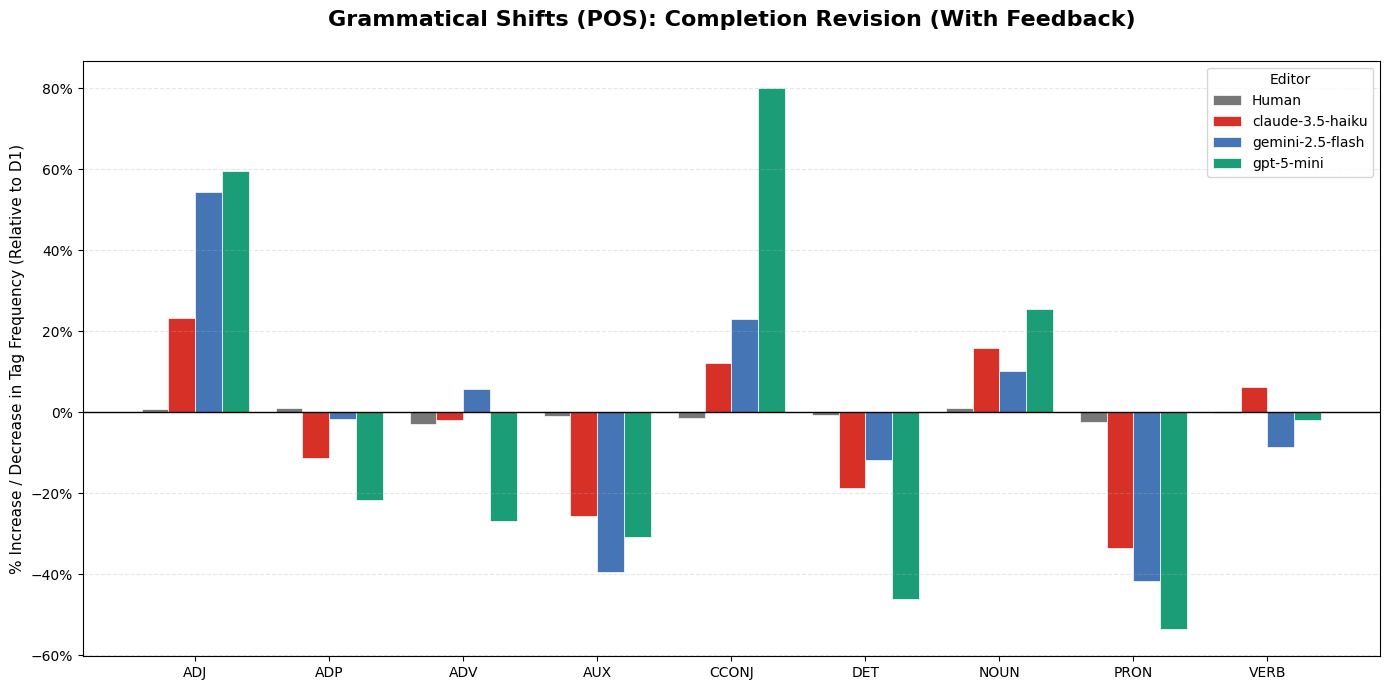

Generating plot for expansion (NO_FB)...


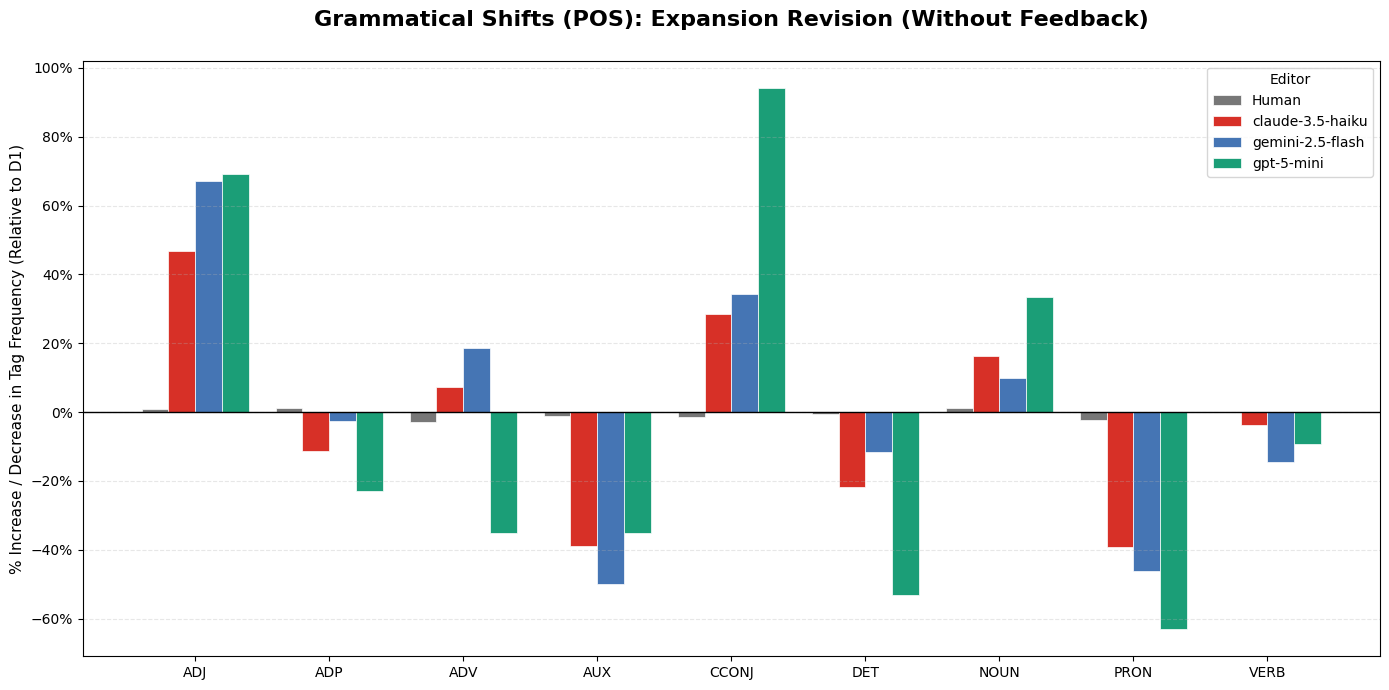

Generating plot for expansion (WITH_FB)...


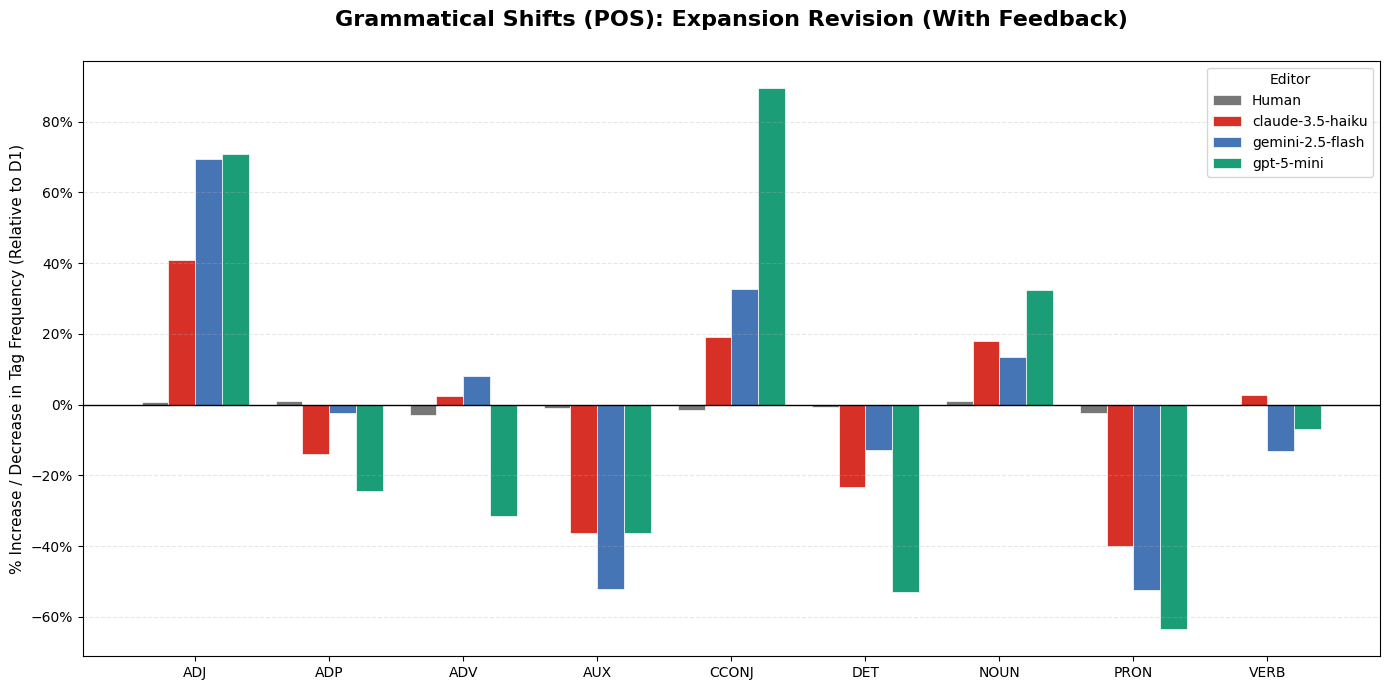

In [6]:
import os, re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import spacy
from matplotlib.ticker import PercentFormatter

# --- 1. CONFIGURATION ---
# Replace with your actual paths
NRC_LEXICON_PATH = Path("../NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")
ARGREWRITE_ROOT = Path("../ArgRewrite").resolve()
D1_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft1"
D2_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft2"

# Use the exact keys from your folder naming convention
COLOR_MAP = {
    "Human": "#777777",
    "CLAUDE-HAIKU-4-5-20251001": "#d73027",
    "GEMINI-2.5-FLASH": "#4575b4",
    "GPT-5-MINI": "#1b9e77"
}

LLM_DISPLAY_NAMES = {
    "CLAUDE-HAIKU-4-5-20251001": "claude-3.5-haiku",
    "GEMINI-2.5-FLASH": "gemini-2.5-flash",
    "GPT-5-MINI": "gpt-5-mini"
}

# The POS tags we care about for stylistic analysis
POS_TAGS = ["ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "NOUN", "PRON", "VERB"]
PLOT_ORDER = ["general", "minimal", "grammar", "completion", "expansion"]

# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
except Exception:
    print("Downloading spaCy model...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

# --- 2. UTILITY FUNCTIONS ---

def super_clean_id(filename):
    nums = re.findall(r"(\d+)", str(filename))
    return str(int(nums[-1])) if nums else str(filename).split('.')[0].strip().lower()

def load_dir_texts(folder: Path):
    texts = {}
    if folder.is_dir():
        for fn in os.listdir(folder):
            if fn.lower().endswith(".txt"):
                eid = super_clean_id(fn)
                with open(folder / fn, "r", encoding="utf-8", errors="ignore") as f:
                    texts[eid] = f.read().strip()
    return texts

def get_pos_vector(text):
    """Calculates the frequency % of each POS tag in the text."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.zeros(len(POS_TAGS))
    
    doc = nlp(text)
    counts = {p: 0 for p in POS_TAGS}
    total = 0
    for token in doc:
        tag = token.pos_
        if tag in counts:
            counts[tag] += 1
            total += 1
    
    if total == 0: return np.zeros(len(POS_TAGS))
    # Return array of percentages (e.g., 15.2 for 15.2%)
    return np.array([(counts[p] / total) * 100.0 for p in POS_TAGS])

# --- 3. PLOTTING ENGINE ---

def plot_combined_pos_bars(mode, feedback_status, data_subset, df_h):
    models = sorted(data_subset['llm_model'].unique())
    
    # Calculate Human Baseline Relative Change
    h_d1 = np.mean([get_pos_vector(t) for t in df_h['draft1']], axis=0)
    h_d2 = np.mean([get_pos_vector(t) for t in df_h['draft2']], axis=0)
    # Relative shift: ((New - Old) / Old) * 100
    h_rel_change = np.where(h_d1 > 0, ((h_d2 - h_d1) / h_d1) * 100, 0)

    plot_dict = {"Human": h_rel_change} 
    
    for m_tag in models:
        m_df = data_subset[data_subset['llm_model'] == m_tag]
        ai_vec = np.mean([get_pos_vector(t) for t in m_df['ai_text']], axis=0)
        d1_vec = np.mean([get_pos_vector(t) for t in m_df['draft1']], axis=0)
        
        m_rel_change = np.where(d1_vec > 0, ((ai_vec - d1_vec) / d1_vec) * 100, 0)
        plot_dict[m_tag] = m_rel_change

    fig, ax = plt.subplots(figsize=(14, 7))
    x_indices = np.arange(len(POS_TAGS))
    n_groups = len(plot_dict)
    bar_width = 0.8 / n_groups

    for i, (key, values) in enumerate(plot_dict.items()):
        color = COLOR_MAP.get(key, "#999999") 
        label = LLM_DISPLAY_NAMES.get(key, key)
        offset = (i - (n_groups - 1) / 2) * bar_width
        ax.bar(x_indices + offset, values, width=bar_width, label=label, 
               color=color, edgecolor='white', linewidth=0.5)

    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("% Increase / Decrease in Tag Frequency (Relative to D1)", fontsize=11)
    
    clean_mode = mode.replace("_", " ").title()
    clean_fb = "With Feedback" if feedback_status == "WITH_FB" else "Without Feedback"
    ax.set_title(f"Grammatical Shifts (POS): {clean_mode} Revision ({clean_fb})", 
                 fontsize=16, pad=25, fontweight='bold')

    ax.set_xticks(x_indices)
    ax.set_xticklabels(POS_TAGS, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.yaxis.set_major_formatter(PercentFormatter())
    
    ax.legend(title="Editor", loc='best', frameon=True)
    plt.tight_layout()
    plt.show()

# --- 4. DATA LOADING ---

print("Loading human essays...")
d1_map = load_dir_texts(D1_PATH)
d2_map = load_dir_texts(D2_PATH)
common_ids = sorted(set(d1_map.keys()) & set(d2_map.keys()), key=lambda x: int(x))
df_human = pd.DataFrame([{"essay_id": eid, "draft1": d1_map[eid], "draft2": d2_map[eid]} for eid in common_ids])

print("Loading LLM drafts...")
all_data_list = []
MODEL_DIRS = [p for p in Path(".").iterdir() if p.is_dir() and p.name.startswith("llm_drafts")]

for folder in MODEL_DIRS:
    model_tag = folder.name.replace("llm_drafts_", "").upper()
    if model_tag not in LLM_DISPLAY_NAMES: continue
    
    for csv_path in folder.glob("*.csv"):
        # Match revision mode
        v_key = "general" if any(x in csv_path.name.lower() for x in ["expert", "general"]) \
                else next((v for v in PLOT_ORDER if v in csv_path.name.lower()), None)
        if not v_key: continue
        
        ldf = pd.read_csv(csv_path)
        ldf['essay_id'] = ldf['essay_id'].apply(super_clean_id)
        ai_col = 'output_text' if 'output_text' in ldf.columns else 'final_llm_text'
        
        merged = pd.merge(df_human, ldf[['essay_id', ai_col]], on='essay_id').rename(columns={ai_col: 'ai_text'})
        merged['llm_model'], merged['mode'] = model_tag, v_key
        merged['feedback'] = "WITH_FB" if "with_FB" in csv_path.name else "NO_FB"
        all_data_list.append(merged)

# --- 5. EXECUTION ---

if all_data_list:
    df_master = pd.concat(all_data_list)
    print(f"Total rows to process: {len(df_master)}")
    
    for mode in PLOT_ORDER:
        for fb in ["NO_FB", "WITH_FB"]:
            subset = df_master[(df_master['mode'] == mode) & (df_master['feedback'] == fb)]
            if not subset.empty:
                print(f"Generating plot for {mode} ({fb})...")
                plot_combined_pos_bars(mode, fb, subset, df_human)
else:
    print("Error: No LLM data found. Check your 'llm_drafts_' folder names and CSV contents.")